# E-Commerce Customer Segmentation

**Two K-Means approaches: customer value/volume and RFM behaviour**

This project analyses transactional data from a UK-based online retailer and develops two complementary customer-segmentation cases:

1. **Quantity and Spending Segmentation** — an improved version of the original project idea.
2. **RFM Segmentation** — a broader behavioural approach based on recency, frequency and monetary value.

Both cases operate at **customer level**, so each observation represents one customer rather than one invoice.

## 1. Setup and Data Loading

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
NROWS = 25_000
DATA_PATH = Path(r"E:\data\OnlineRetail.csv")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Update DATA_PATH in the setup cell before running the notebook."
    )

df_raw = pd.read_csv(DATA_PATH, nrows=NROWS)
print(f"Raw dataset shape: {df_raw.shape}")
display(df_raw.head())

Raw dataset shape: (25000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 2. Data Quality and Preparation

The preparation stage:

- parses transaction dates,
- removes duplicate records,
- excludes records without a customer identifier from customer-level analysis,
- distinguishes completed sales from cancellations and returns,
- calculates transaction value as `Quantity × UnitPrice`.

In [3]:
quality_summary = pd.DataFrame({
    "Data type": df_raw.dtypes.astype(str),
    "Missing values": df_raw.isna().sum(),
    "Missing %": (df_raw.isna().mean() * 100).round(2),
    "Unique values": df_raw.nunique()
})

display(quality_summary)
print(f"Duplicate rows: {df_raw.duplicated().sum():,}")

,Data type,Missing values,Missing %,Unique values
InvoiceNo,object,0,0.00,1166
StockCode,object,0,0.00,2540
Description,object,111,0.44,2478
Quantity,int64,0,0.00,173
InvoiceDate,object,0,0.00,990
UnitPrice,float64,0,0.00,226
CustomerID,float64,8944,35.78,654
Country,object,0,0.00,18


Duplicate rows: 352


In [4]:
df = df_raw.copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df = df.drop_duplicates()

# Customer-level analysis requires a valid customer identifier.
df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype("Int64").astype(str)

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["IsReturn"] = df["InvoiceNo"].str.startswith("C") | (df["Quantity"] < 0)
df["TotalValue"] = df["Quantity"] * df["UnitPrice"]

sales = df.loc[
    (~df["IsReturn"])
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
    & df["InvoiceDate"].notna()
].copy()

returns = df.loc[df["IsReturn"]].copy()

cleaning_summary = pd.Series({
    "Customer-linked transactions": len(df),
    "Completed sales transactions": len(sales),
    "Return/cancellation transactions": len(returns),
    "Unique customers in completed sales": sales["CustomerID"].nunique(),
    "Unique completed invoices": sales["InvoiceNo"].nunique()
}, name="Count")

display(cleaning_summary.to_frame())

,Count
Customer-linked transactions,15705
Completed sales transactions,15348
Return/cancellation transactions,356
Unique customers in completed sales,608
Unique completed invoices,840


## 3. Exploratory Customer and Transaction Analysis

### 3.1 Customer Purchase Frequency

,Purchase Frequency
count,608.000000
mean,1.381579
std,1.795782
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,34.000000


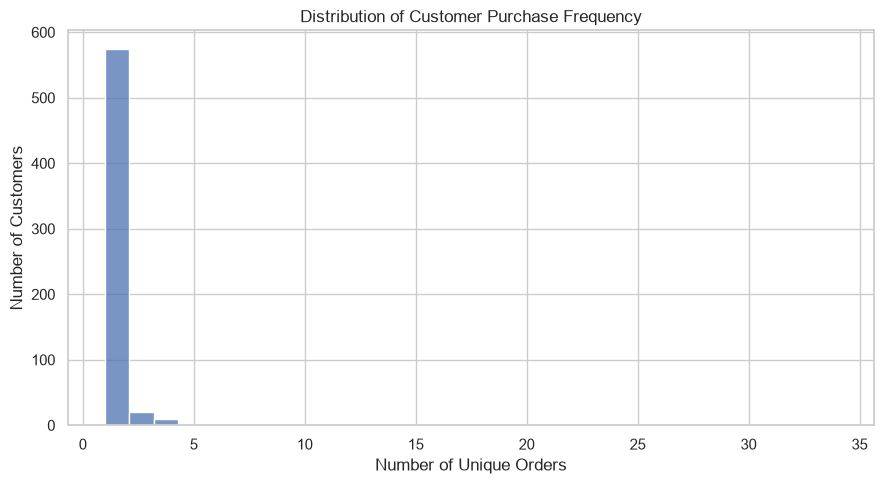

In [5]:
customer_frequency = (
    sales.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

display(customer_frequency.describe().to_frame("Purchase Frequency"))

plt.figure(figsize=(9, 5))
sns.histplot(customer_frequency, bins=30)
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Unique Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

The distribution is typically right-skewed: most customers purchase only a small number of times, while a smaller group returns frequently. This pattern supports the use of segmentation rather than treating the customer base as homogeneous.

### 3.2 Most Returned Products

,StockCode,Description,ReturnedQuantity,ReturnTransactions
239,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,1
143,22588,CARD HOLDER GINGHAM HEART,192,1
138,22574,HEART WOODEN CHRISTMAS DECORATION,192,1
31,21232,STRAWBERRY CERAMIC TRINKET BOX,148,2
87,22130,PARTY CONE CHRISTMAS DECORATION,144,1
146,22595,CHRISTMAS GINGHAM HEART,144,1
145,22593,CHRISTMAS GINGHAM STAR,144,1
172,22752,SET 7 BABUSHKA NESTING BOXES,98,2
184,22834,HAND WARMER BABUSHKA DESIGN,72,1
141,22580,ADVENT CALENDAR GINGHAM SACK,60,3


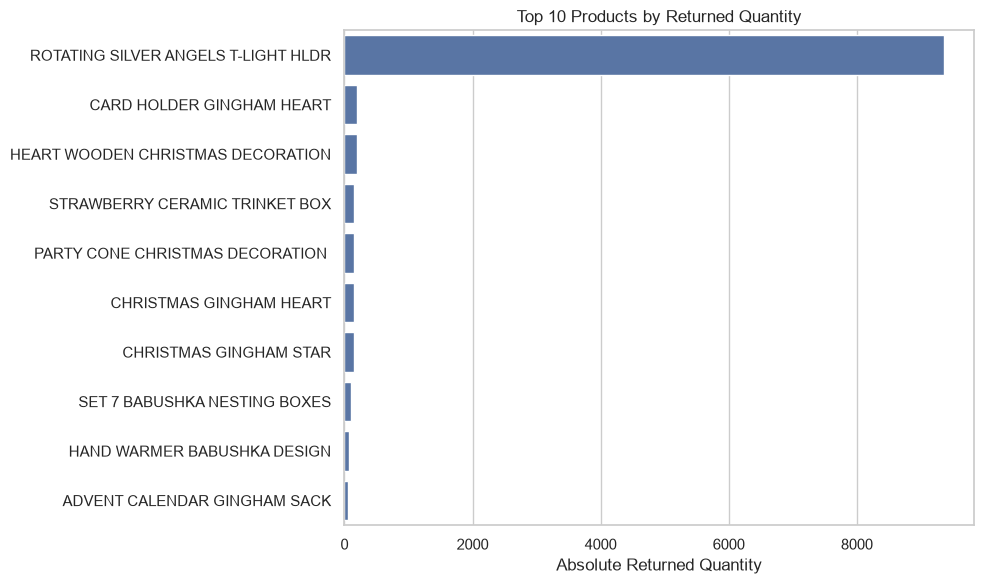

In [6]:
top_returns = (
    returns.dropna(subset=["Description"])
    .groupby(["StockCode", "Description"], as_index=False)
    .agg(
        ReturnedQuantity=("Quantity", lambda x: abs(x.sum())),
        ReturnTransactions=("InvoiceNo", "nunique")
    )
    .sort_values("ReturnedQuantity", ascending=False)
    .head(10)
)

display(top_returns)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_returns,
    x="ReturnedQuantity",
    y="Description"
)
plt.title("Top 10 Products by Returned Quantity")
plt.xlabel("Absolute Returned Quantity")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 3.3 UK versus International Order Values

,count,mean,median,std
Market,,,,
Outside United Kingdom,64,595.11,352.18,651.70
United Kingdom,776,384.76,254.78,791.17


Mann–Whitney U statistic: 18,539
p-value: 0.000744


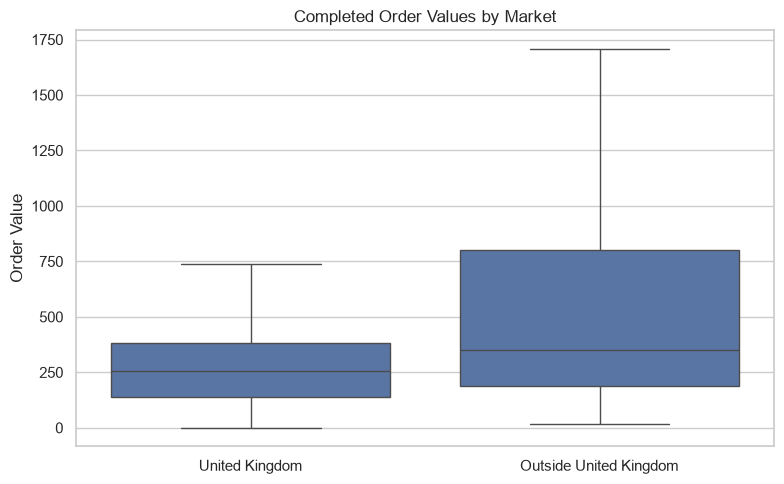

In [7]:
invoice_values = (
    sales.groupby(["InvoiceNo", "Country"], as_index=False)
    .agg(OrderValue=("TotalValue", "sum"))
)

invoice_values["Market"] = np.where(
    invoice_values["Country"].eq("United Kingdom"),
    "United Kingdom",
    "Outside United Kingdom"
)

market_summary = (
    invoice_values.groupby("Market")["OrderValue"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

display(market_summary)

uk_orders = invoice_values.loc[
    invoice_values["Market"].eq("United Kingdom"), "OrderValue"
]
international_orders = invoice_values.loc[
    invoice_values["Market"].eq("Outside United Kingdom"), "OrderValue"
]

u_statistic, p_value = mannwhitneyu(
    uk_orders,
    international_orders,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {u_statistic:,.0f}")
print(f"p-value: {p_value:.4g}")

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=invoice_values,
    x="Market",
    y="OrderValue",
    showfliers=False
)
plt.title("Completed Order Values by Market")
plt.xlabel("")
plt.ylabel("Order Value")
plt.tight_layout()
plt.show()

The comparison is performed at **invoice level**, rather than by comparing total country quantities. The Mann–Whitney U test evaluates whether the two order-value distributions differ without assuming normality. Statistical significance should be considered together with the group medians and the practical size of the difference.

### 3.4 Highest-Spending Customers

In [8]:
top_customers = (
    sales.groupby("CustomerID", as_index=False)
    .agg(
        TotalSpent=("TotalValue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        ItemsPurchased=("Quantity", "sum")
    )
    .sort_values("TotalSpent", ascending=False)
    .head(10)
)

display(top_customers)

,CustomerID,TotalSpent,Orders,ItemsPurchased
592,18102,27834.61,4,6695
251,15061,17344.78,11,8070
128,13777,6840.16,9,3552
235,14911,5567.63,9,2356
548,17850,5391.21,34,1733
376,16210,4738.54,2,1866
357,16029,4271.52,3,1936
32,12755,3794.40,1,1488
6,12433,3787.12,2,3582
490,17381,3603.72,3,2888


## 4. Case A — Quantity and Spending Segmentation

This case preserves the original project idea but corrects the unit of analysis.

The original version aggregated data by `InvoiceNo`, meaning that each observation represented an order. For customer segmentation, the correct level is `CustomerID`.

The two clustering variables are:

- `TotalQuantityPurchased = sum(Quantity)`
- `TotalSpent = sum(Quantity × UnitPrice)`

`Orders` is retained only for interpreting the resulting clusters; it is not used as a clustering feature.

In [9]:
customer_value = (
    sales.groupby("CustomerID", as_index=False)
    .agg(
        TotalQuantityPurchased=("Quantity", "sum"),
        TotalSpent=("TotalValue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)

customer_value = customer_value.loc[
    (customer_value["TotalQuantityPurchased"] > 0)
    & (customer_value["TotalSpent"] > 0)
].copy()

print(f"Customers available for Case A: {len(customer_value):,}")
display(customer_value.head())
display(
    customer_value[
        ["TotalQuantityPurchased", "TotalSpent", "Orders"]
    ].describe().round(2)
)

Customers available for Case A: 608


,CustomerID,TotalQuantityPurchased,TotalSpent,Orders
0,12347,319,711.79,1
1,12386,214,258.90,1
2,12395,528,346.10,1
3,12427,79,303.50,1
4,12429,454,1281.50,1


,TotalQuantityPurchased,TotalSpent,Orders
count,608.00,608.00,608.00
mean,278.24,553.71,1.38
std,588.28,1465.09,1.80
min,1.00,15.00,1.00
25%,75.00,183.64,1.00
50%,133.50,307.47,1.00
75%,250.00,470.47,1.00
max,8070.00,27834.61,34.00


### 5.1 Feature Distributions

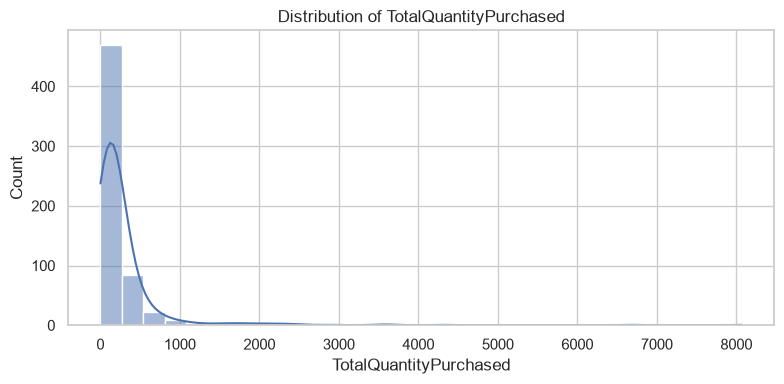

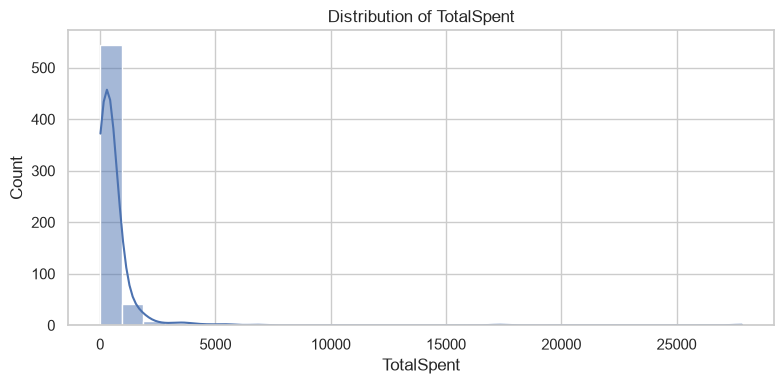

In [10]:
for feature in ["TotalQuantityPurchased", "TotalSpent"]:
    plt.figure(figsize=(8, 4))
    sns.histplot(customer_value[feature], bins=30, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

Both variables are usually strongly right-skewed. A small number of customers purchase very large quantities or generate very high spending. Therefore, the features are transformed with `log1p` before standardisation and clustering.

In [11]:
case_a_features = customer_value[
    ["TotalQuantityPurchased", "TotalSpent"]
].copy()

case_a_log = np.log1p(case_a_features)

case_a_scaler = StandardScaler()
case_a_scaled = case_a_scaler.fit_transform(case_a_log)

### 5.2 Selecting the Number of Clusters

,k,Inertia,Silhouette
0,2,583.4579,0.4873
1,3,340.2226,0.4627
2,4,251.7057,0.4166
3,5,189.7157,0.4237
4,6,158.3607,0.3790
5,7,138.7572,0.3543
6,8,124.1423,0.3435


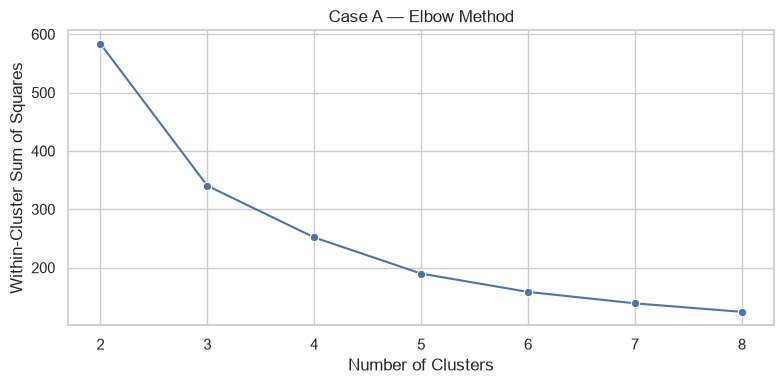

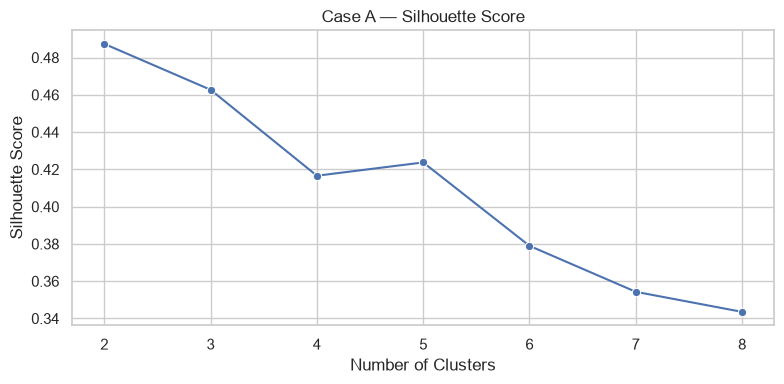

In [12]:
case_a_model_selection = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(case_a_scaled)

    case_a_model_selection.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(case_a_scaled, labels)
    })

case_a_model_selection = pd.DataFrame(case_a_model_selection)
display(case_a_model_selection.round(4))

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=case_a_model_selection,
    x="k",
    y="Inertia",
    marker="o"
)
plt.title("Case A — Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=case_a_model_selection,
    x="k",
    y="Silhouette",
    marker="o"
)
plt.title("Case A — Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

The final number of clusters is selected using the highest silhouette score. The diagnostic table and elbow plot should still be reviewed to confirm that the result provides useful business segments.

In [13]:
CASE_A_K = int(
    case_a_model_selection.loc[
        case_a_model_selection["Silhouette"].idxmax(),
        "k"
    ]
)

print(f"Selected number of clusters for Case A: {CASE_A_K}")

case_a_kmeans = KMeans(
    n_clusters=CASE_A_K,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE
)

customer_value["ValueCluster"] = case_a_kmeans.fit_predict(case_a_scaled)

Selected number of clusters for Case A: 2


### 5.3 Customer Segments

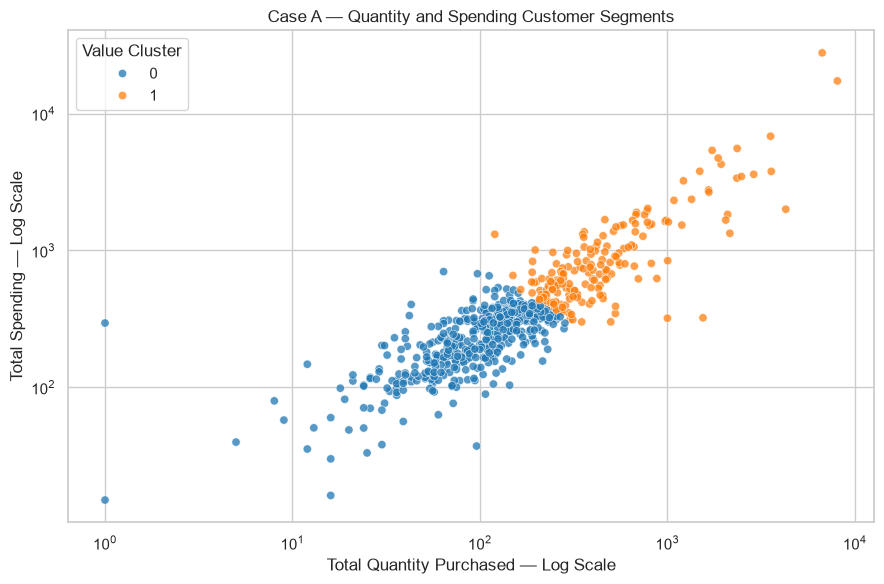

In [14]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=customer_value,
    x="TotalQuantityPurchased",
    y="TotalSpent",
    hue="ValueCluster",
    palette="tab10",
    alpha=0.75
)
plt.xscale("log")
plt.yscale("log")
plt.title("Case A — Quantity and Spending Customer Segments")
plt.xlabel("Total Quantity Purchased — Log Scale")
plt.ylabel("Total Spending — Log Scale")
plt.legend(title="Value Cluster")
plt.tight_layout()
plt.show()

### 5.4 Cluster Profiles

In [15]:
case_a_profile = (
    customer_value.groupby("ValueCluster")
    .agg(
        Customers=("CustomerID", "count"),
        MedianQuantity=("TotalQuantityPurchased", "median"),
        MedianSpent=("TotalSpent", "median"),
        MedianOrders=("Orders", "median"),
        MeanQuantity=("TotalQuantityPurchased", "mean"),
        MeanSpent=("TotalSpent", "mean"),
        MeanOrders=("Orders", "mean")
    )
)

case_a_profile["CustomerShare_%"] = (
    case_a_profile["Customers"]
    / case_a_profile["Customers"].sum()
    * 100
)

display(case_a_profile.round(2).sort_values("MeanSpent", ascending=False))

,Customers,MedianQuantity,MedianSpent,MedianOrders,MeanQuantity,MeanSpent,MeanOrders,CustomerShare_%
ValueCluster,,,,,,,,
1,181,388.0,702.1,1.0,681.18,1296.28,2.03,29.77
0,427,103.0,230.1,1.0,107.43,238.95,1.11,70.23


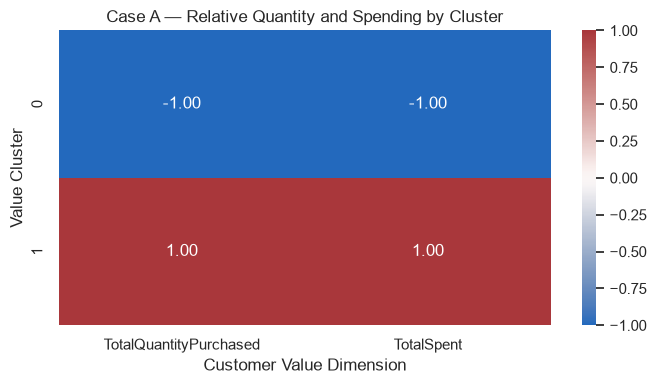

In [16]:
case_a_heatmap = (
    customer_value.groupby("ValueCluster")[
        ["TotalQuantityPurchased", "TotalSpent"]
    ]
    .mean()
)

case_a_heatmap_scaled = pd.DataFrame(
    StandardScaler().fit_transform(case_a_heatmap),
    index=case_a_heatmap.index,
    columns=case_a_heatmap.columns
)

plt.figure(figsize=(7, 4))
sns.heatmap(
    case_a_heatmap_scaled,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)
plt.title("Case A — Relative Quantity and Spending by Cluster")
plt.xlabel("Customer Value Dimension")
plt.ylabel("Value Cluster")
plt.tight_layout()
plt.show()

### Case A Interpretation

This segmentation answers a direct commercial question:

> Which customers buy the largest quantities, and which customers generate the greatest spending?

Possible profiles include low-volume/low-spend customers, high-volume/high-spend customers and customers whose quantity and spending patterns do not move proportionally. Final labels should be assigned after inspecting the calculated cluster profiles.

## 5. Case B — RFM Customer Segmentation

The second approach extends the analysis beyond customer quantity and spending.

Customers are segmented using the established **RFM framework**:

- **Recency:** Days since the customer's most recent purchase
- **Frequency:** Number of unique completed orders
- **Monetary:** Total amount spent by the customer

Extreme upper-tail values are capped at the 99th percentile to prevent a small number of customers from dominating the K-Means solution.

Four clusters are selected to provide a more actionable business interpretation:

- Champions
- Loyal Customers
- At Risk
- Low Engagement

In [ ]:
analysis_date = sales["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    sales.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate",lambda x: (analysis_date - x.max()).days),
        Frequency=("InvoiceNo","nunique"),
        Monetary=("TotalValue","sum")).reset_index())

# Keep only customers with positive purchasing activity.
rfm = rfm.loc[
    (rfm["Frequency"] > 0)
    & (rfm["Monetary"] > 0)
].copy()

print(f"Customers available for RFM segmentation: {len(rfm):,}")

display(rfm.head())

display(
    rfm[
        ["Recency", "Frequency", "Monetary"]
    ].describe().round(2)
)

Customers available for RFM segmentation: 608


,CustomerID,Recency,Frequency,Monetary
0,12347,3,1,711.79
1,12386,3,1,258.90
2,12395,7,1,346.10
3,12427,8,1,303.50
4,12429,2,1,1281.50


,Recency,Frequency,Monetary
count,608.00,608.00,608.00
mean,4.97,1.38,553.71
std,2.93,1.80,1465.09
min,1.00,1.00,15.00
25%,2.00,1.00,183.64
50%,5.00,1.00,307.47
75%,8.00,1.00,470.47
max,10.00,34.00,27834.61


### 5.1 RFM Feature Distributions

RFM variables are generally right-skewed.

A small number of customers may have exceptionally high order frequency or spending. These extreme observations can strongly influence the cluster centres.

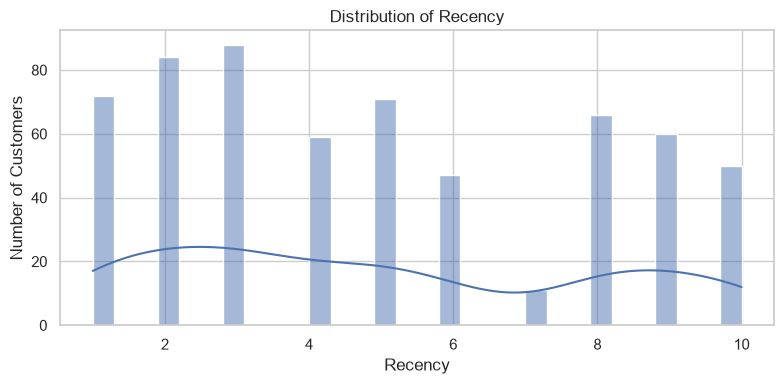

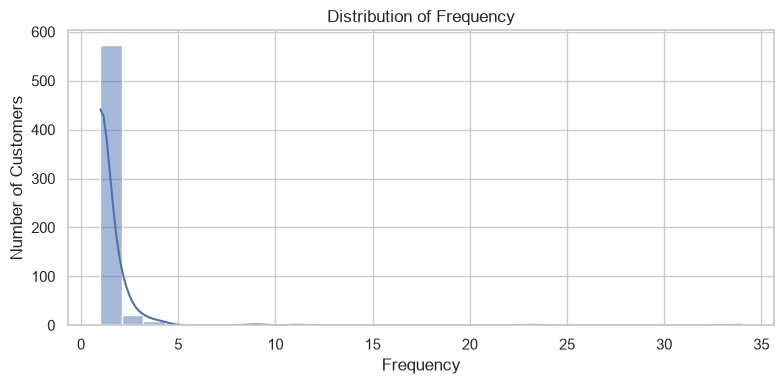

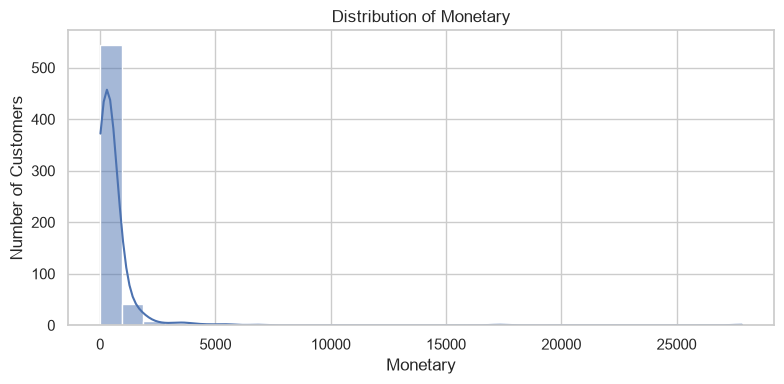

In [18]:
for feature in ["Recency", "Frequency", "Monetary"]:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=rfm,
        x=feature,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

### 5.2 Treatment of Extreme Values

Instead of deleting customers, values above the 99th percentile are capped.

This preserves all customers in the analysis while reducing the influence of extreme observations on K-Means.

In [19]:
rfm_model = rfm.copy()

outlier_limits = {}

for feature in ["Recency", "Frequency", "Monetary"]:

    upper_limit = rfm_model[feature].quantile(0.99)

    outlier_limits[feature] = upper_limit

    rfm_model[feature] = rfm_model[feature].clip(
        upper=upper_limit
    )

outlier_limits = pd.Series(
    outlier_limits,
    name="99th Percentile Cap"
)

display(outlier_limits.to_frame().round(2))

,99th Percentile Cap
Recency,10.00
Frequency,4.00
Monetary,4238.12


In [20]:
outlier_comparison = pd.DataFrame({
    "Original Maximum": rfm[
        ["Recency", "Frequency", "Monetary"]
    ].max(),

    "Capped Maximum": rfm_model[
        ["Recency", "Frequency", "Monetary"]
    ].max()
})

display(outlier_comparison.round(2))

,Original Maximum,Capped Maximum
Recency,10.00,10.00
Frequency,34.00,4.00
Monetary,27834.61,4238.12


### 5.3 Transformation and Standardisation

A `log1p` transformation is applied to reduce positive skewness.

The transformed variables are then standardised so that Recency, Frequency and Monetary contribute on a comparable scale.

In [21]:
rfm_features = rfm_model[
    ["Recency", "Frequency", "Monetary"]
].copy()

rfm_log = np.log1p(rfm_features)

rfm_scaler = StandardScaler()

rfm_scaled = rfm_scaler.fit_transform(
    rfm_log
)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=[
        "Recency",
        "Frequency",
        "Monetary"
    ],
    index=rfm.index
)

display(rfm_scaled_df.head())

,Recency,Frequency,Monetary
0,-0.488331,-0.456695,0.949594
1,-0.488331,-0.456695,-0.229793
2,0.790821,-0.456695,0.108416
3,1.008181,-0.456695,-0.044654
4,-1.019227,-0.456695,1.636238


### 5.4 Evaluation of the Number of Clusters

The elbow method and silhouette score are calculated for diagnostic purposes.

The final model uses four clusters because the objective is to create commercially interpretable customer groups rather than selecting clusters solely according to the maximum silhouette score.

In [22]:
rfm_model_selection = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(
        rfm_scaled
    )

    rfm_model_selection.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(
            rfm_scaled,
            labels
        )
    })

rfm_model_selection = pd.DataFrame(
    rfm_model_selection
)

display(
    rfm_model_selection.round(4)
)

,k,Inertia,Silhouette
0,2,1129.4847,0.4723
1,3,777.6957,0.3761
2,4,645.1971,0.3387
3,5,539.8303,0.3558
4,6,462.3370,0.3437
5,7,412.3842,0.3472
6,8,371.0141,0.3414


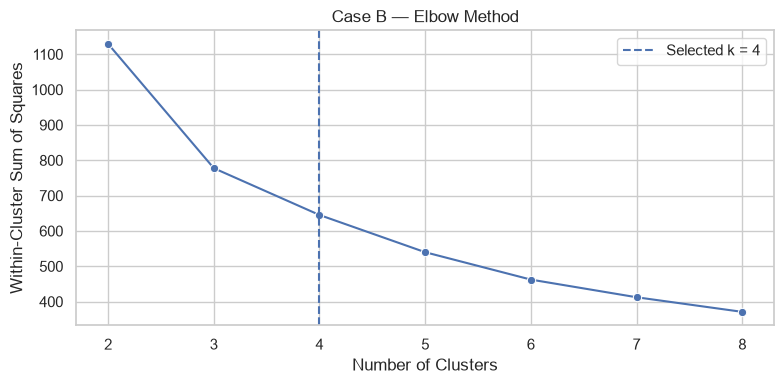

In [23]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=rfm_model_selection,
    x="k",
    y="Inertia",
    marker="o"
)

plt.axvline(
    x=4,
    linestyle="--",
    label="Selected k = 4"
)

plt.title("Case B — Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")
plt.legend()

plt.tight_layout()
plt.show()

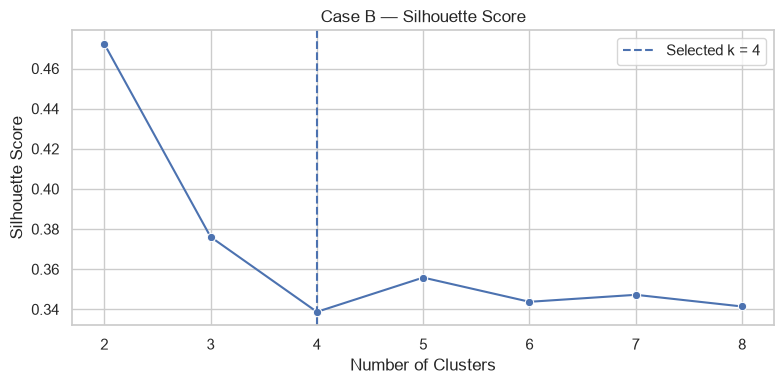

In [24]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=rfm_model_selection,
    x="k",
    y="Silhouette",
    marker="o"
)

plt.axvline(
    x=4,
    linestyle="--",
    label="Selected k = 4"
)

plt.title("Case B — Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.legend()

plt.tight_layout()
plt.show()

### 5.5 Final Four-Cluster K-Means Model

A four-cluster solution is used to create customer groups that can support retention, loyalty and reactivation strategies.

In [25]:
RFM_K = 4

rfm_kmeans = KMeans(
    n_clusters=RFM_K,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE
)

rfm_labels = rfm_kmeans.fit_predict(
    rfm_scaled
)

# Keep original uncapped RFM values for interpretation.
rfm["RFMCluster"] = rfm_labels

rfm_silhouette = silhouette_score(
    rfm_scaled,
    rfm_labels
)

print(f"Selected number of clusters: {RFM_K}")
print(
    f"Silhouette score for k=4: "
    f"{rfm_silhouette:.4f}"
)

Selected number of clusters: 4
Silhouette score for k=4: 0.3387


### 5.6 Initial Cluster Profiles

Cluster labels generated by K-Means are arbitrary.

Therefore, the clusters must first be examined according to their actual Recency, Frequency and Monetary characteristics.

In [26]:
rfm_cluster_profile = (
    rfm.groupby("RFMCluster")
    .agg(
        Customers=(
            "CustomerID",
            "count"
        ),
        MedianRecency=(
            "Recency",
            "median"
        ),
        MedianFrequency=(
            "Frequency",
            "median"
        ),
        MedianMonetary=(
            "Monetary",
            "median"
        ),
        MeanRecency=(
            "Recency",
            "mean"
        ),
        MeanFrequency=(
            "Frequency",
            "mean"
        ),
        MeanMonetary=(
            "Monetary",
            "mean"
        )
    )
)

rfm_cluster_profile["CustomerShare_%"] = (
    rfm_cluster_profile["Customers"]
    / rfm_cluster_profile["Customers"].sum()
    * 100
)

display(
    rfm_cluster_profile
    .round(2)
    .sort_values(
        "MeanMonetary",
        ascending=False
    )
)

,Customers,MedianRecency,MedianFrequency,MedianMonetary,MeanRecency,MeanFrequency,MeanMonetary,CustomerShare_%
RFMCluster,,,,,,,,
3,105,3.0,2.0,745.00,3.42,3.09,1590.18,17.27
0,124,5.0,1.0,520.33,4.93,1.00,676.10,20.39
2,144,2.0,1.0,228.45,1.96,1.02,246.16,23.68
1,235,8.0,1.0,203.30,7.53,1.04,214.49,38.65


### 5.7 Data-Driven Segment Naming

The four numeric cluster labels are converted into business segment names according to their RFM profiles.

- **Champions:** Recent, frequent and high-value customers
- **Loyal Customers:** Relatively recent customers with repeated purchasing activity
- **At Risk:** Previously valuable customers who have not purchased recently
- **Low Engagement:** Infrequent, low-value and inactive customers

In [27]:
profile_for_scoring = (
    rfm.groupby("RFMCluster")[[
        "Recency",
        "Frequency",
        "Monetary"
    ]]
    .mean()
)

profile_scores = pd.DataFrame(
    StandardScaler().fit_transform(
        profile_for_scoring
    ),
    index=profile_for_scoring.index,
    columns=profile_for_scoring.columns
)

# Champions: low recency, high frequency and high monetary value.
profile_scores["ChampionScore"] = (
    -profile_scores["Recency"]
    + profile_scores["Frequency"]
    + profile_scores["Monetary"]
)

champion_cluster = profile_scores["ChampionScore"].idxmax()

remaining_clusters = [
    cluster
    for cluster in profile_scores.index
    if cluster != champion_cluster
]

# At Risk: high recency but historically stronger frequency/value.
profile_scores["AtRiskScore"] = (
    profile_scores["Recency"]
    + profile_scores["Frequency"]
    + profile_scores["Monetary"]
)

at_risk_cluster = (
    profile_scores
    .loc[remaining_clusters, "AtRiskScore"]
    .idxmax()
)

remaining_clusters = [
    cluster
    for cluster in remaining_clusters
    if cluster != at_risk_cluster
]

# Low Engagement: high recency, low frequency and low monetary value.
profile_scores["LowEngagementScore"] = (
    profile_scores["Recency"]
    - profile_scores["Frequency"]
    - profile_scores["Monetary"]
)

low_engagement_cluster = (
    profile_scores
    .loc[remaining_clusters, "LowEngagementScore"]
    .idxmax()
)

loyal_cluster = [
    cluster
    for cluster in remaining_clusters
    if cluster != low_engagement_cluster
][0]

segment_mapping = {
    champion_cluster: "Champions",
    loyal_cluster: "Loyal Customers",
    at_risk_cluster: "At Risk",
    low_engagement_cluster: "Low Engagement"
}

rfm["Segment"] = rfm["RFMCluster"].map(segment_mapping)

print("Cluster-to-segment mapping:")

for cluster, segment in segment_mapping.items():
    print(f"Cluster {cluster}: {segment}")

Cluster-to-segment mapping:
Cluster 3: Champions
Cluster 2: Loyal Customers
Cluster 1: At Risk
Cluster 0: Low Engagement


In [28]:
segment_profile = (
    rfm.groupby("Segment")
    .agg(
        Customers=(
            "CustomerID",
            "count"
        ),
        MedianRecency=(
            "Recency",
            "median"
        ),
        MedianFrequency=(
            "Frequency",
            "median"
        ),
        MedianMonetary=(
            "Monetary",
            "median"
        ),
        MeanRecency=(
            "Recency",
            "mean"
        ),
        MeanFrequency=(
            "Frequency",
            "mean"
        ),
        MeanMonetary=(
            "Monetary",
            "mean"
        )
    )
)

segment_profile["CustomerShare_%"] = (
    segment_profile["Customers"]
    / segment_profile["Customers"].sum()
    * 100
)

display(segment_profile.round(2))

,Customers,MedianRecency,MedianFrequency,MedianMonetary,MeanRecency,MeanFrequency,MeanMonetary,CustomerShare_%
Segment,,,,,,,,
At Risk,235,8.0,1.0,203.30,7.53,1.04,214.49,38.65
Champions,105,3.0,2.0,745.00,3.42,3.09,1590.18,17.27
Low Engagement,124,5.0,1.0,520.33,4.93,1.00,676.10,20.39
Loyal Customers,144,2.0,1.0,228.45,1.96,1.02,246.16,23.68


### 5.8 PCA Visualisation

Principal Component Analysis is used only for two-dimensional visualisation.

The K-Means model itself is trained using all three scaled RFM variables.

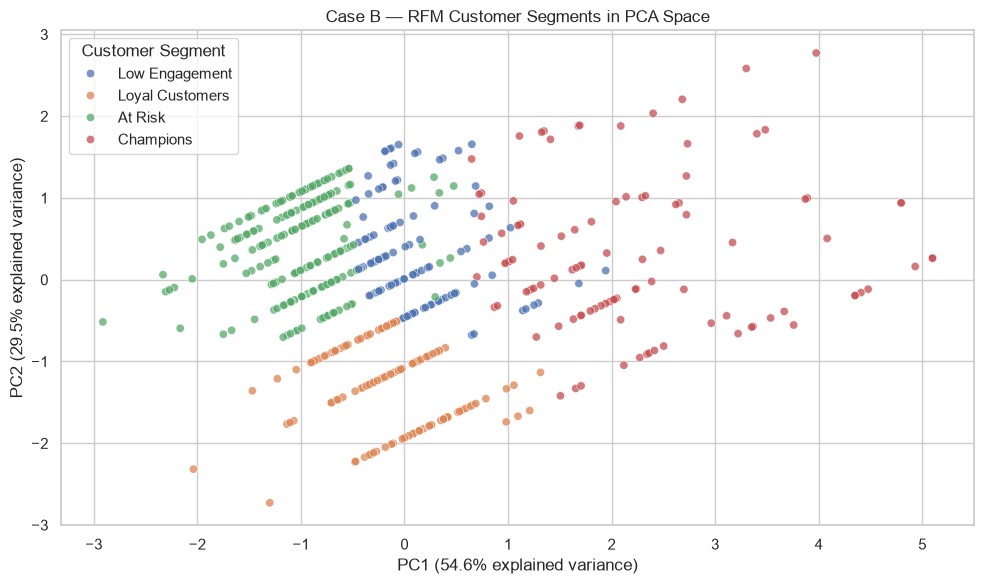

In [29]:
rfm_pca_model = PCA(
    n_components=2
)

rfm_pca = rfm_pca_model.fit_transform(
    rfm_scaled
)

rfm_pca_df = pd.DataFrame({
    "PC1": rfm_pca[:, 0],
    "PC2": rfm_pca[:, 1],
    "Segment": rfm["Segment"].values
})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm_pca_df,
    x="PC1",
    y="PC2",
    hue="Segment",
    alpha=0.75
)

plt.title(
    "Case B — RFM Customer Segments in PCA Space"
)

plt.xlabel(
    f"PC1 "
    f"({rfm_pca_model.explained_variance_ratio_[0]:.1%} "
    f"explained variance)"
)

plt.ylabel(
    f"PC2 "
    f"({rfm_pca_model.explained_variance_ratio_[1]:.1%} "
    f"explained variance)"
)

plt.legend(title="Customer Segment")

plt.tight_layout()
plt.show()

### 5.9 Business Interpretation

The four RFM segments support different customer-management strategies:

| Segment | Behaviour | Suggested Action |
|---|---|---|
| Champions | Recent, frequent and high-spending customers | Loyalty rewards, exclusive offers and retention |
| Loyal Customers | Repeated purchasing activity and relatively recent engagement | Cross-selling and personalised recommendations |
| At Risk | Historically valuable customers with reduced recent activity | Win-back and reactivation campaigns |
| Low Engagement | Infrequent, low-value and inactive customers | Low-cost automated campaigns |

The segment names are based on the observed cluster profiles rather than the arbitrary numeric labels produced by K-Means.

## 6. Comparing the Two Segmentation Cases

| Case | Clustering Variables | Main Business Question | Best Use |
|---|---|---|---|
| Case A | Total quantity and total spending | Who buys the most and who creates the most revenue? | Commercial value tiers and sales targeting |
| Case B | Recency, frequency and monetary value | Who is active, loyal, valuable or at risk? | CRM, retention and reactivation campaigns |

The cases are complementary rather than competing:

- **Case A** retains the original project logic and focuses on purchase volume and economic value.
- **Case B** adds the time and frequency dimensions needed for broader customer-lifecycle analysis.

In [31]:
cluster_comparison = (
    customer_value[
        ["CustomerID", "ValueCluster"]
    ]
    .merge(
        rfm[["CustomerID", "RFMCluster"]],
        on="CustomerID",
        how="inner"
    )
)

comparison_table = pd.crosstab(
    cluster_comparison["ValueCluster"],
    cluster_comparison["RFMCluster"],
    normalize="index"
).mul(100).round(1)

comparison_table.index.name = "Value Cluster"
comparison_table.columns.name = "RFM Cluster"

print("Percentage distribution of RFM clusters within each value cluster:")
display(comparison_table)

Percentage distribution of RFM clusters within each value cluster:


RFM Cluster,0,1,2,3
Value Cluster,,,,
0,10.1,52.2,30.7,7.0
1,44.8,6.6,7.2,41.4


The cross-tabulation shows whether customers with similar spending and quantity patterns also share similar recency and frequency behaviour. A high-value customer may still belong to an at-risk RFM segment if they have not purchased recently.

## 7. Business Interpretation

### Case A — Quantity and Spending

Potential segment descriptions include:

- low quantity and low spending,
- high quantity and high spending,
- high quantity but moderate spending,
- lower quantity but high-value purchasing.

### Case B — RFM

Potential RFM segment descriptions include:

| Behaviour | Possible Segment | Example Action |
|---|---|---|
| Low recency, high frequency, high monetary value | Champions | Retention, exclusivity and loyalty rewards |
| Low recency, moderate frequency and value | Potential Loyalists | Cross-selling and personalised recommendations |
| High recency, historically strong value | At Risk | Reactivation and win-back campaigns |
| High recency, low frequency and low value | Low Engagement | Low-cost automated campaigns |

Numeric cluster labels have no inherent business meaning. Final names should be assigned only after examining the calculated cluster profiles.

## 8. Conclusion

This project now presents two valid K-Means customer-segmentation stories.

The first case improves the original idea by calculating total quantity and actual spending at customer level. The second case extends the analysis through the established RFM framework.

Together, the two approaches distinguish between:

- **customer commercial value**, captured by quantity and spending;
- **customer engagement and lifecycle behaviour**, captured by recency, frequency and monetary value.

This makes the project more complete while preserving the original analytical concept.

## 9. Limitations

- The analysis uses the first `25,000` rows when `NROWS=25_000`; results may differ when the full dataset is used.
- K-Means is sensitive to scaling, outliers and the selected number of clusters.
- Cluster labels are descriptive and should be validated against future customer behaviour.
- Quantity and spending may be strongly correlated, so Case A should be interpreted primarily as a commercial-value segmentation.
- Campaign recommendations should be validated through controlled experiments.